In [102]:
#load dependencies
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import sklearn
import sklearn.model_selection
from sklearn.preprocessing import StandardScaler,MinMaxScaler
import tensorflow as tf
from sklearn.metrics import mean_squared_error, r2_score

import datetime
import h5py 

# Q1. Get familiar with TensorFlow APIs
https://www.tensorflow.org/versions/r2.10/api_docs/python/tf



tf - GradientTape, tensor, tensor array, tensor shape, variable, constat

tf.autodiff

tf.bitwise

tf.image

tf.keras/  (will use most of the time, need to be familiar with all modules/functions...)

    - simple operations using tensorflow - add, subtract, dot product

    - take batch of data and do the mean, rms

    - layers -  normalization,  conv1D, average pooling, max pooling,  global average pooling, global max pooling,   batch 

    - normalization, average, add, subtract, multiply, maximum, minimum, dot, zeropadding, concatenate, conv1D transpose, dense, flatten, upsampling1D, activation,

    - regression - loss - different types available in tf - mean absolute error, mean absolute percentage error, mean squared error, 

    - metrices - accuracy, mean, mean absolute error, mean absolute percentage error, mean squared error, rmse

    - optimizer - adagrad, adam,SGD

    - regularizer - L1, L2, L1L2, 

    - utils - array_to_image, image_to_array, set_random_seed, timeseries_data_from_array

tf.math - argmax, floor, exp ...

tf.signal- fft, ifft ...

tf.test - compute_gradient


In [ ]:
# define a tensor and do some operations
a=tf.constant([
    [4.0, 5.0],
    [1.0, 2.0]
])

b=tf.constant([
    [2.0, 3.0],
    [7.0, 8.0]
])

ab_add=tf.add(a,b)
ab_subtract=tf.subtract(a,b)
ab_matmul=tf.matmul(a,b)
ab_concat=tf.concat([a,b], axis=0)
print(f'additon of matrix a = \n{a} and  \n b= \n{b} is \n ab_concat=\n{ab_concat}')



additon of matrix a = 
[[4. 5.]
 [1. 2.]] and  
 b= 
[[2. 3.]
 [7. 8.]] is 
 ab_concat=
[[4. 5.]
 [1. 2.]
 [2. 3.]
 [7. 8.]]


# Q2. Like wise look at the APIs to get familiar with differnt functionalities

# Q3 For autonomous mobile robot (AMR), it is desirable to apply precise voltage to motors so that its speed can be controlled. The transfer equation as provioded by manufacturer is as follows rpm= 2+5*V, where rpm  is motror rpm and V is the applied voltage.

It is desirable to validate the transfer function. So experiement is carried out to validate the functionality of motor. 

1. Below is the experimental data.

2. Perform the following operations
- read the data
- divide the data in three subsets - train, val, test. check their dimensionality
- make a simple 1 layer, 1 node (dense layer) regression model
- add layers and nodes, 1D cnn, dense layer, activation function ....
- train model with loss and optimization
- evaluate the model on val data set
- tune the model architecture, if val KPI is not ok
- Freeze the model and save
- load the model
- make predictions (test the model on test data set)
- quantify the predictions in terms of accuracies KPIs
- Make interpretation of your test results
- Summarize the over all process

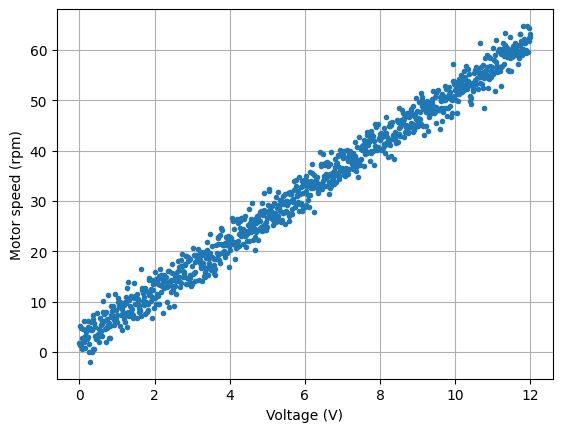

Train data (X_train): (800, 1) 
 Train label (y_train): (800,)  
      
 Val data (X_val): (100, 1) 
 Val label (y_val): (100,) 
      
 Test data (X_test): (100, 1) 
 Test label (y_test): (100,)
      
Model: "sequential_27"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 normalization_28 (Normaliza  (None, 1)                3         
 tion)                                                           
                                                                 
 dense_39 (Dense)            (None, 1)                 2         
                                                                 
Total params: 5
Trainable params: 2
Non-trainable params: 3
_________________________________________________________________


In [ ]:
# generate data
# Generate 1000 voltage values from 0 V to 12 V #x
V = np.linspace(0, 12, 1000) #x

# Calculate motor speed #y
rpm = 2 + 5 * V 

# Generate white Gaussian noise with mean 0 and standard deviation 2
noise = np.random.normal(0, 2, size=V.shape)
#noise = np.random.uniform(-10, 10, V.shape)

rpm_noisy=rpm+noise

#plot the measurement data
plt.plot(V, rpm_noisy,'.')
plt.xlabel("Voltage (V)")
plt.ylabel("Motor speed (rpm)")
plt.grid(True)
plt.show()

# Split data into training, validation, and test sets. add random_seed to split the data deterministically each time we run the program.
# with out this - the program splits the data differently. 80-20 split
X_train, X_rem, y_train, y_rem = sklearn.model_selection.train_test_split(
    V, rpm, test_size=0.2, random_state=7
)

#10-10 split
X_val, X_test, y_val, y_test = sklearn.model_selection.train_test_split(
    X_rem, y_rem, test_size=0.5, random_state=7
)

#print dimenstion of train,val and test. Note that the dimension is in list. we need to convert to array
# print(f'''Train data (X_train): {np.shape(X_train)} \n Train label (y_train): {np.shape(y_train)}  
#       \n Val data (X_val): {np.shape(X_val)} \n Val label (y_val): {np.shape(y_val)} 
#       \n Test data (X_test): {np.shape(X_test)} \n Test label (y_test): {np.shape(y_test)}
#       ''')


# Reshape features to 2D as expected by tf, np ...
X_train = X_train.reshape(-1, 1) #shape - number of examples, number of features
X_val = X_val.reshape(-1, 1)
X_test = X_test.reshape(-1, 1)



print(f'''Train data (X_train): {np.shape(X_train)} \n Train label (y_train): {np.shape(y_train)}  
      \n Val data (X_val): {np.shape(X_val)} \n Val label (y_val): {np.shape(y_val)} 
      \n Test data (X_test): {np.shape(X_test)} \n Test label (y_test): {np.shape(y_test)}
      ''')

# TO DO: print some samples of X_train and y_train

# TO DO: print some samples of X_val, y_val


#ML model - define a ML model with 1 layer and 1 neuron without activation function
model = tf.keras.Sequential([
    tf.keras.layers.Normalization(input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(1)
])

#learns mean, std from training data at normalization layerand uses it during training
model.layers[0].adapt(X_train) 

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# model summary - paramaters 
model.summary() 

In [ ]:
#train model
EPOCHS=50
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),  
    epochs=EPOCHS,
    batch_size=8
)

#check  parameters - loss 
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)


#loss
plt.figure()
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch Number')
plt.ylabel("Loss (mse)")
plt.legend()
plt.grid(True)
plt.show()


#acccuracy
plt.figure()
plt.plot(history.history['mae'], label='train accuracy')
plt.plot(history.history['val_mae'], label='val accuracy')
plt.xlabel('Epoch Number')
plt.ylabel("Accuracy (mae)")
plt.legend()
plt.grid(True)
plt.show()




4/4 [==============================] - 0s 2ms/step


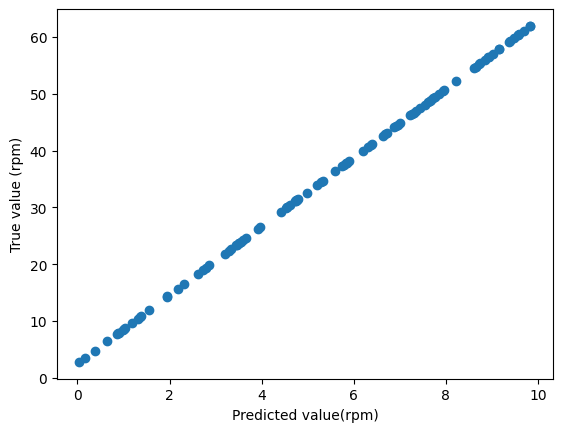

loss(mean squared error on test data):1088.589 
  accuracy(mean absolute error):29.753
Test data R2 score: -2.728


In [ ]:
# TO DO: save model

# TO DO: load model

# predictions on test data set
y_hat = model.predict(X_test)  #y_hat

plt.figure()
plt.scatter(y_hat, y_test)
plt.xlabel('Predicted value(rpm)')
plt.ylabel('True value (rpm)')
plt.show()


#evaluate on test data set
results = model.evaluate(X_test, y_test, verbose=0)
print('loss(mean squared error on test data):{:.3f} \n  accuracy(mean absolute error):{:.3f}'.format(results[0],results[1]))

#r2 score
r2score_test = r2_score(y_test, y_hat)
print("Test data R2 score: {:.3f}".format(r2score_test)) # between -inf to 1. close to 1 better

# Q4 Consider the above example as baseline. Develope a robust ML model such that prediction made of test data has minimal rmse and $R^2\approx1$

- Feel free to use, different layers - Conv1D, Dense, maxpooling, average pooling; optimization algorithm, loss function, epochs, various layers, differnt neurons in each layer 

- Validate your method by showing 
    - Graphical comparison between loss and accuracy between baseline model and your model
    - Graphical comparison between True value vs Predicted value between baseline model and your model
    - Graphical comparision between test accuracy and $R^2$

# Q5. Regression forward pass
Find the first forward pass output of the NN as explained in image.png. The activation function at each node in hidden layer is ReLu, and output layer do not have activation function. The input, weights and biases are as follows:

$x=[[1],[5],[7]
]$

$W=[[1.1, 2.8, 2.9],
[0.2, 0.11, 5],
[1.11, 2.8, 3.8],
[4.7, 5.8, 0.001]]$

$b=[[0.5], 
    [0.8],
    [0.99],
    [0.87]]$



![alt text](image.png)

# Q6. The file insurance.csv contains the cost of insurance depending upon different features. Perform the following tasks.

From now when ever there is features, it means all, except region.

- Check the data integrity. Check if there are NAN values.
- Display few examples
- Find the statistics of each features and target variable. 
- Show the histogram together with how Gaussian probability distribution fits the features and labels. Also find the mean and std of each features and labels.
- Develop a ML model to find the cost of insurance depending upon different features (except region). Display the train, val, test data dimension, loss and accuracy curve, True vs Predicted values, $R^2$. Remember to validate your model on val data to see before you test your model on test data set.


# Q7. Find the output from output layer of the model that contains 
- Input dimension = 3x1
- First hidden layer has 4 neurons
- Second hidden layer has 4 neurons
- Output layer has 1 neuron. Remember output layer do not have activation function

assign random weights and bias at each layer



# Q8. Repeat Q7 with ReLu activation function. Remember output layer do not have activation function

# Q9. Solve the following
$$
\mathbf{x} \gets \mathbb{Z}^{+^{10\times1}}; \quad \mathbf{x} \in [1,10]\\
\mathbf{y} \gets \beta_0+\beta_1\mathbf{x}+N;  \quad \theta=[\beta_0,\beta_1]=[1,2], \quad N \sim \mathcal{N}(2,1) \\
\text{Find a function $f$ with parameter $\hat{\theta}$}  \\
f_{\hat{\theta}}:\mathbf{x} \rightarrow \mathbf{\hat{y}} \quad | \quad min \quad \mathcal{L}(\mathbf{y},{\hat{\mathbf{y}}} )
$$